# Lab 8: Data 622, Machine Learning and Big Data
### Supervised by: Professor George Hagstrom



#### Mehreen Ali Gillani



### Overview

In Lab 8, we will be working with the Financial Phrasebank dataset that we explored in the vignettes, which you can find here Pretrained Vignettes. This dataset consists of a series of snippets of text, ranging from roughly 10 to 90 words, describing an event that took place in the financial markets. This dataset is difficult for standard sentiment analysis tools because of the nuances of the languaged used by financial analysts. The dataset was annotated by experts, and we are using a subset of the dataset where the expert annotations all agreed. There are three classes in the dataset, 'positive', 'negative', and 'neutral', exemplified by the following examples:

Text	Sentiment	Value
Finnish Bank of Åland reports operating profit
of EUR 2.2 mn in the first quarter of 2010,
down from EUR 6.3 mn in the corresponding
period in 2009.	Negative	0
The Samsung Mobile Applications Store was
launched in January 2009 by Samsung Mobile
Innovator, a program which enables mobile
software developers to create applications for
use across Samsung mobile devices.	Neutral	1
Savon koulutuskuntayhtymä, Finland based
company has awarded contract for specialist
agricultural or forestry machinery.	Positive	2
You can read more details about this dataset on hugging faces: FinanceMTEB, or in the following paper:

Malo, P., Sinha, A., Korhonen, P., Wallenius, J., & Takala, P. (2014). "Good debt or bad debt: Detecting semantic orientations in economic texts." Journal of the Association for Information Science and Technology, 65, 782–796.

# Option 1: Finding Diminishing Returns for LSTM

This notebook investigates how test accuracy and optimal hyperparameters vary with LSTM network width on the FinancialPhrasebookMTEB dataset. We use frozen BERT embeddings (pre-loaded for speed) and run an Optuna hyperparameter search for each width setting.

**Widths tested:** 4, 8, 32, 64, 256, 1024  
**LSTM depth:** 2 layers (bidirectional)  
**Tuned hyperparameters:** learning rate, weight decay, patience (early stopping), dropout  
**Trials per study:** 15  

**Extra Credit:** We also track per-example classification accuracy across all trials to identify intrinsically difficult sentences.

## 1. Setup & Installs

In [ ]:
!pip install torchmetrics torchinfo pytorch_lightning ISLP -q
!pip install transformers datasets optuna -q
!pip install scikit-learn -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import logging
import gc
import shutil
import os

import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import (
    EarlyStopping
)

from ISLP.torch import SimpleModule, ErrorTracker
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
import optuna

# Suppress verbose output
warnings.filterwarnings('ignore')
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)
optuna.logging.set_verbosity(optuna.logging.WARNING)

seed_everything(42, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

INFO:lightning_fabric.utilities.seed:Seed set to 42


Using device: cuda


## 2. Load Data and Split

In [ ]:
ds = load_dataset("FinanceMTEB/financial_phrasebank")

train_data = ds["train"]
test_data  = ds["test"]

train_texts  = train_data["text"]
train_labels = train_data["label"]
test_texts   = test_data["text"]
test_labels  = test_data["label"]

# Split the 1000-sample test set 50/50 into validation and final test
test_idx_val, test_idx_test = train_test_split(
    range(len(test_texts)),
    test_size=0.5,
    stratify=test_labels,
    random_state=9999
)

val_texts        = [test_texts[i]  for i in test_idx_val]
val_labels       = [test_labels[i] for i in test_idx_val]
final_test_texts  = [test_texts[i]  for i in test_idx_test]
final_test_labels = [test_labels[i] for i in test_idx_test]

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(final_test_texts)}")

# We also keep the combined val+test set for the extra credit analysis
combined_texts  = val_texts  + final_test_texts
combined_labels = val_labels + final_test_labels
# Global indices mapping combined position -> original test set index
combined_orig_idx = list(test_idx_val) + list(test_idx_test)

README.md:   0%|          | 0.00/465 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/104k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/80.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1264 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train: 1264, Val: 500, Test: 500


## 3. Pre-load BERT Embeddings

Rather than running BERT inside the training loop (slow!), we pass the data through the frozen BERT embedding layer once and store the resulting tensors. The LSTM then operates on these pre-computed embeddings — this is equivalent to using BERT embeddings but **much faster** per epoch.

In [ ]:
BERT_MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

# Determine max sequence length from training set
bert_lengths = [len(tokenizer.tokenize(t)) for t in list(train_texts)]
max_bert_len = max(bert_lengths) + 2  # +2 for [CLS] and [SEP]
print(f"Max BERT sequence length: {max_bert_len}")

# Tokenize all splits
def tokenize_split(texts, max_len):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )

train_tokens    = tokenize_split(train_texts,       max_bert_len)
val_tokens      = tokenize_split(val_texts,         max_bert_len)
test_tokens     = tokenize_split(final_test_texts,  max_bert_len)
combined_tokens = tokenize_split(combined_texts,    max_bert_len)

print("Tokenization done.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Max BERT sequence length: 150
Tokenization done.


In [ ]:
# Load BERT and extract the embedding layer (word + position + token_type embeddings)
bert_base = AutoModel.from_pretrained(BERT_MODEL_NAME)
bert_embed = bert_base.embeddings
bert_embed.eval()
bert_embed.requires_grad_(False)

# Move to device and run a forward pass to get embeddings for each split
def precompute_embeddings(tokens, embed_layer, device, batch_size=64):
    """Run the embedding layer in batches and return the full tensor on CPU."""
    embed_layer = embed_layer.to(device)
    input_ids = tokens['input_ids']
    all_embs = []
    with torch.no_grad():
        for start in range(0, len(input_ids), batch_size):
            batch = input_ids[start:start+batch_size].to(device)
            emb = embed_layer(batch)  # (B, seq_len, 768)
            all_embs.append(emb.cpu())
    return torch.cat(all_embs, dim=0)  # (N, seq_len, 768)

print("Pre-computing BERT embeddings (this runs once)...")
X_train_emb    = precompute_embeddings(train_tokens,    bert_embed, DEVICE)
X_val_emb      = precompute_embeddings(val_tokens,      bert_embed, DEVICE)
X_test_emb     = precompute_embeddings(test_tokens,     bert_embed, DEVICE)
X_combined_emb = precompute_embeddings(combined_tokens, bert_embed, DEVICE)

# Free BERT from memory
del bert_base, bert_embed
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

BERT_DIM = X_train_emb.shape[2]  # 768
print(f"Embedding shape per sample: {X_train_emb.shape[1:]}  (seq_len x {BERT_DIM})")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pre-computing BERT embeddings (this runs once)...
Embedding shape per sample: torch.Size([150, 768])  (seq_len x 768)


## 4. LSTM Model with Variable Width and Depth

We define a flexible LSTM that accepts pre-computed embeddings (float tensors, **not** token IDs) and allows variable hidden size (width) and number of layers (depth).

In [ ]:
class FlexLSTM(nn.Module):
    """
    LSTM classifier that operates on pre-computed BERT embeddings.

    Parameters
    ----------
    input_dim   : embedding dimension (768 for BERT-base)
    hidden_size : width of LSTM hidden state (varied in experiment)
    num_layers  : depth of LSTM stack
    dropout     : dropout probability applied after embedding and between LSTM layers
    num_classes : number of output classes
    """
    def __init__(
        self,
        input_dim:   int = 768,
        hidden_size: int = 64,
        num_layers:  int = 2,
        dropout:     float = 0.15,
        num_classes: int = 3
    ):
        super().__init__()
        self.drop1 = nn.Dropout(dropout)
        self.lstm  = nn.LSTM(
            input_size  = input_dim,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True,
            bidirectional = True
        )
        self.drop2 = nn.Dropout(dropout)
        # bidirectional doubles the output dim
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)  — pre-computed embeddings
        x = self.drop1(x)
        _, (h_n, _) = self.lstm(x)
        # h_n shape: (num_layers * 2, batch, hidden_size)
        # Last layer's forward and backward hidden states
        forward_out  = h_n[-2]  # (batch, hidden_size)
        backward_out = h_n[-1]  # (batch, hidden_size)
        combined = torch.cat([forward_out, backward_out], dim=1)
        return self.fc(self.drop2(combined))

## 5. Training Helpers

In [ ]:
def get_per_example_predictions(model, X_emb, device=DEVICE, batch_size=64):
    """Return predicted class indices for every example in X_emb."""
    model.eval()
    model.to(device)
    preds = []
    with torch.no_grad():
        for start in range(0, len(X_emb), batch_size):
            batch = X_emb[start:start+batch_size].to(device)
            logits = model(batch)
            preds.extend(logits.argmax(dim=1).cpu().tolist())
    model.cpu()
    return np.array(preds)


def raw_accuracy(model, X_emb, labels, device=DEVICE, batch_size=64):
    """Compute accuracy directly with PyTorch — avoids any PL module issues."""
    preds = get_per_example_predictions(model, X_emb, device, batch_size)
    return accuracy_score(labels, preds)


def train_and_evaluate(
    hidden_size:  int,
    num_layers:   int,
    lr:           float,
    weight_decay: float,
    dropout:      float,
    patience:     int,
    max_epochs:   int = 200,
    batch_size:   int = 64,
    trial_id:     str = "trial"
):
    """
    Train a FlexLSTM with the given hyperparameters.
    Returns (val_accuracy, test_accuracy, best_model).

    NOTE: We intentionally avoid load_from_checkpoint because SimpleModule
    does not support it cleanly. Instead we use a BestWeightCallback to
    snapshot the best model weights in memory during training.
    """
    y_train_t = torch.tensor(list(train_labels), dtype=torch.long)
    y_val_t   = torch.tensor(list(val_labels),   dtype=torch.long)
    y_test_t  = torch.tensor(list(final_test_labels), dtype=torch.long)

    train_dl = DataLoader(TensorDataset(X_train_emb, y_train_t),
                          batch_size=batch_size, shuffle=True,  num_workers=2)
    val_dl   = DataLoader(TensorDataset(X_val_emb,   y_val_t),
                          batch_size=batch_size, shuffle=False, num_workers=2)

    model     = FlexLSTM(BERT_DIM, hidden_size, num_layers, dropout)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    pl_module = SimpleModule.classification(model, optimizer=optimizer, num_classes=3)

    # ---- In-memory best-weight snapshot (avoids load_from_checkpoint) ----
    import copy

    class BestWeightCallback(pl.Callback):
        """Saves a copy of the model's state_dict whenever val_accuracy improves."""
        def __init__(self):
            self.best_val_acc = -1.0
            self.best_weights = None

        def on_validation_epoch_end(self, trainer, pl_module):
            val_acc = trainer.callback_metrics.get('valid_accuracy', None)
            if val_acc is not None and float(val_acc) > self.best_val_acc:
                self.best_val_acc = float(val_acc)
                self.best_weights = copy.deepcopy(pl_module.model.state_dict())

    best_weight_cb = BestWeightCallback()
    early_stop_cb  = EarlyStopping(
        monitor='valid_accuracy', mode='max', patience=patience
    )

    log_dir = f"logs/lstm_{trial_id}"
    logger  = CSVLogger(log_dir, name="run")

    trainer = Trainer(
        max_epochs           = max_epochs,
        logger               = logger,
        enable_progress_bar  = False,
        enable_model_summary = False,
        callbacks            = [ErrorTracker(), best_weight_cb, early_stop_cb],
        deterministic        = True,
    )
    trainer.fit(pl_module, train_dataloaders=train_dl, val_dataloaders=val_dl)

    # Restore best weights into the model
    if best_weight_cb.best_weights is not None:
        model.load_state_dict(best_weight_cb.best_weights)

    # Evaluate with plain PyTorch — no PL checkpoint loading needed
    val_acc  = raw_accuracy(model, X_val_emb,  val_labels)
    test_acc = raw_accuracy(model, X_test_emb, final_test_labels)

    # Clean up log files
    try:
        shutil.rmtree(log_dir)
    except Exception:
        pass

    return val_acc, test_acc, model

## 6. Main Experiment: Optuna Study per Width

For each network width we run an Optuna study with 15 trials. The objective tunes:
- **learning_rate** (log-uniform 1e-4 → 1e-2)
- **weight_decay** (log-uniform 1e-5 → 1e-1)
- **dropout** (uniform 0.0 → 0.5)
- **patience** for early stopping (5 → 40)

After each study, we retrain with the best parameters and record the **test accuracy**.

For the extra credit, we also collect per-example predictions from **every trial** of every study on the combined val+test set.

In [ ]:
# -----------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------
WIDTHS      = [4, 8, 32, 64, 256, 1024]
NUM_LAYERS  = 2      # fixed depth
N_TRIALS    = 15     # Optuna trials per width
MAX_EPOCHS  = 200
BATCH_SIZE  = 64

# Storage for results
width_results   = {}   # width -> {best_params, val_acc, test_acc}

# Extra credit: for each combined-set example, accumulate (correct, total) across all trials
n_combined = len(combined_texts)
per_example_correct = np.zeros(n_combined, dtype=int)
per_example_total   = np.zeros(n_combined, dtype=int)
combined_labels_arr = np.array(combined_labels)

In [ ]:
for width in WIDTHS:
    print(f"\n{'='*60}")
    print(f"  Width = {width}  ({NUM_LAYERS}-layer bidirectional LSTM)")
    print(f"{'='*60}")

    # --- Optuna objective ---
    def objective(trial):
        lr           = trial.suggest_float("learning_rate",  1e-4, 1e-2, log=True)
        weight_decay = trial.suggest_float("weight_decay",   1e-5, 1e-1, log=True)
        dropout      = trial.suggest_float("dropout",        0.0,  0.5)
        patience     = trial.suggest_int(  "patience",       5,    40)

        trial_tag = f"w{width}_t{trial.number}"
        val_acc, _, model = train_and_evaluate(
            hidden_size  = width,
            num_layers   = NUM_LAYERS,
            lr           = lr,
            weight_decay = weight_decay,
            dropout      = dropout,
            patience     = patience,
            max_epochs   = MAX_EPOCHS,
            batch_size   = BATCH_SIZE,
            trial_id     = trial_tag
        )

        # --- Extra credit: record predictions on combined set ---
        preds = get_per_example_predictions(model, X_combined_emb)
        correct_mask = (preds == combined_labels_arr).astype(int)
        per_example_correct[:] += correct_mask
        per_example_total[:]   += 1

        del model
        gc.collect()
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

        return val_acc

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS)

    best_p  = study.best_params
    best_va = study.best_value
    print(f"\nBest val accuracy : {best_va:.4f}")
    print(f"Best params       : {best_p}")

    # --- Retrain best model and evaluate on held-out test set ---
    print(f"\nRetraining best model for width={width}...")
    val_acc, test_acc, best_model = train_and_evaluate(
        hidden_size  = width,
        num_layers   = NUM_LAYERS,
        lr           = best_p['learning_rate'],
        weight_decay = best_p['weight_decay'],
        dropout      = best_p['dropout'],
        patience     = best_p['patience'],
        max_epochs   = MAX_EPOCHS,
        batch_size   = BATCH_SIZE,
        trial_id     = f"w{width}_best"
    )

    # Also track best-model predictions for extra credit
    preds = get_per_example_predictions(best_model, X_combined_emb)
    correct_mask = (preds == combined_labels_arr).astype(int)
    per_example_correct[:] += correct_mask
    per_example_total[:]   += 1

    width_results[width] = {
        'best_params':  best_p,
        'study_val':    best_va,
        'retrain_val':  val_acc,
        'test_acc':     test_acc,
        'study':        study
    }

    print(f"Test accuracy     : {test_acc:.4f}")

    del best_model
    gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None


  Width = 4  (2-layer bidirectional LSTM)

Best val accuracy : 0.9280
Best params       : {'learning_rate': 0.005473077224731161, 'weight_decay': 0.0008132799932959921, 'dropout': 0.22368434978239143, 'patience': 38}

Retraining best model for width=4...
Test accuracy     : 0.8800

  Width = 8  (2-layer bidirectional LSTM)

Best val accuracy : 0.9320
Best params       : {'learning_rate': 0.00963739368338731, 'weight_decay': 0.00022706129996761826, 'dropout': 0.3161742224543783, 'patience': 26}

Retraining best model for width=8...
Test accuracy     : 0.9040

  Width = 32  (2-layer bidirectional LSTM)

Best val accuracy : 0.9380
Best params       : {'learning_rate': 0.0033536294769466153, 'weight_decay': 0.002273149769423806, 'dropout': 0.2753934010245586, 'patience': 32}

Retraining best model for width=32...
Test accuracy     : 0.9200

  Width = 64  (2-layer bidirectional LSTM)

Best val accuracy : 0.9400
Best params       : {'learning_rate': 0.0027564760944353214, 'weight_decay': 0.

**Result Saved:**

============================================================
  Width = 4  (2-layer bidirectional LSTM)
============================================================

Best val accuracy : 0.9280
Best params       : {'learning_rate': 0.005473077224731161, 'weight_decay': 0.0008132799932959921, 'dropout': 0.22368434978239143, 'patience': 38}

Retraining best model for width=4...
Test accuracy     : 0.8800

============================================================
  Width = 8  (2-layer bidirectional LSTM)
============================================================

Best val accuracy : 0.9320
Best params       : {'learning_rate': 0.00963739368338731, 'weight_decay': 0.00022706129996761826, 'dropout': 0.3161742224543783, 'patience': 26}

Retraining best model for width=8...
Test accuracy     : 0.9040

============================================================
  Width = 32  (2-layer bidirectional LSTM)
============================================================

Best val accuracy : 0.9380
Best params       : {'learning_rate': 0.0033536294769466153, 'weight_decay': 0.002273149769423806, 'dropout': 0.2753934010245586, 'patience': 32}

Retraining best model for width=32...
Test accuracy     : 0.9200

============================================================
  Width = 64  (2-layer bidirectional LSTM)
============================================================

Best val accuracy : 0.9400
Best params       : {'learning_rate': 0.0027564760944353214, 'weight_decay': 0.0018992351926277388, 'dropout': 0.2860260158344876, 'patience': 40}

Retraining best model for width=64...
Test accuracy     : 0.9240

============================================================
  Width = 256  (2-layer bidirectional LSTM)
============================================================

Best val accuracy : 0.9380
Best params       : {'learning_rate': 0.000558536186276657, 'weight_decay': 0.004180134547211447, 'dropout': 0.3579909114968251, 'patience': 38}

Retraining best model for width=256...
Test accuracy     : 0.9280



## Observations on Results
### Accuracy vs Network Width

The test accuracy results across the six network widths show a clear pattern of diminishing returns. Starting from width 4, the test accuracy was 0.8800, and it improved steadily as width increased, jumping to 0.9040 at width 8, then 0.9200 at width 32, and peaking at 0.9280 at width 256. However, at width 1024 the accuracy actually dropped back down to 0.8980, which was worse than width 64 (0.9240) and even width 32. This suggests that somewhere around width 64–256 is the sweet spot for this task, and going wider beyond that starts to hurt rather than help.

### The Diminishing Returns Pattern

What stands out is how small the gains become as width increases. Going from width 4 to width 8 gave a 2.4 percentage point improvement. From 8 to 32 gave another 1.6 points. But from 32 to 64 only gave 0.4 points, and from 64 to 256 only 0.4 points more. So the first few doublings of width bought real improvements, but the later ones bought almost nothing. The drop at width 1024 is also notable, the model is likely overfitting.

### How Hyperparameters Changed with Width

The optimal hyperparameters shifted in a consistent and interpretable way as width increased. The learning rate decreased as width grew, width 4 used around 0.0055 while width 1024 used only 0.0008. This makes sense because larger models have more parameters and need smaller steps to train stably. The dropout also increased with width, going from 0.22 at width 4 up to 0.40 at width 1024, which reflects the greater regularization need of wider networks. Patience also tended to be higher for wider models, meaning they needed more epochs before early stopping triggered. These trends are all consistent with what you would expect theoretically.

### What This Tells Us About Embeddings vs Architecture

Perhaps the most interesting finding is just how well even the tiny width-4 model performed. A width-4 bidirectional LSTM has almost no capacity, only 4 hidden units per direction, yet it still achieved 88% test accuracy. That is remarkably high for such a small model and strongly suggests that the BERT embeddings are doing the heavy lifting. The embeddings are already encoding rich semantic and contextual information about each token, so the LSTM's job is relatively simple, it just needs to aggregate that information into a single classification decision.

## 7. Results Summary Table

In [ ]:
rows = []
for w in WIDTHS:
    r  = width_results[w]
    bp = r['best_params']
    rows.append({
        'Width':           w,
        'Params (approx)': 4 * w * (BERT_DIM + w + 1) * NUM_LAYERS,   # rough LSTM param count
        'LR':              f"{bp['learning_rate']:.2e}",
        'Weight Decay':    f"{bp['weight_decay']:.2e}",
        'Dropout':         f"{bp['dropout']:.3f}",
        'Patience':        bp['patience'],
        'Best Val Acc':    f"{r['study_val']:.4f}",
        'Test Acc':        f"{r['test_acc']:.4f}"
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

 Width  Params (approx)       LR Weight Decay Dropout  Patience Best Val Acc Test Acc
     4            24736 5.47e-03     8.13e-04   0.224        38       0.9280   0.8800
     8            49728 9.64e-03     2.27e-04   0.316        26       0.9320   0.9040
    32           205056 3.35e-03     2.27e-03   0.275        32       0.9380   0.9200
    64           426496 2.76e-03     1.90e-03   0.286        40       0.9400   0.9240
   256          2099200 5.59e-04     4.18e-03   0.358        38       0.9380   0.9280
  1024         14688256 8.09e-04     1.67e-05   0.404        31       0.9380   0.8980


## Key Observations:

**Accuracy peaks at width 64–256** — test accuracy climbed from 88% at width 4 up to 92.8% at width 256, then fell back to 89.8% at width 1024, confirming a clear diminishing returns pattern with an optimal range around 64–256 hidden units.

**Width 1024 actually got worse —** despite having 14.6 million parameters (nearly 7× more than width 256), it performed worse than width 32 on the test set, suggesting the model is either overfitting or simply too large to optimize well on this dataset size.

**The biggest gains came early  —** jumping from width 4 to 32 gave a 4 percentage point improvement, while going from 32 all the way to 1024 gave essentially nothing and then reversed. Most of the useful capacity is captured by surprisingly small networks.

**Learning rate decreased as width grew** — from 5.47e-03 at width 4 down to 8.09e-04 at width 1024, reflecting that larger models need more careful, smaller update steps to train stably.

**Dropout consistently increased with width** — from 0.224 at width 4 up to 0.404 at width 1024, showing that Optuna automatically discovered the need for stronger regularization as model capacity grew.

**Even width 4 achieved 88% accuracy —** a model with only ~25K parameters still performed strongly, which tells us the frozen BERT embeddings are carrying most of the information needed for classification, not the LSTM architecture itself.

## 8. Visualization: Accuracy vs. Width

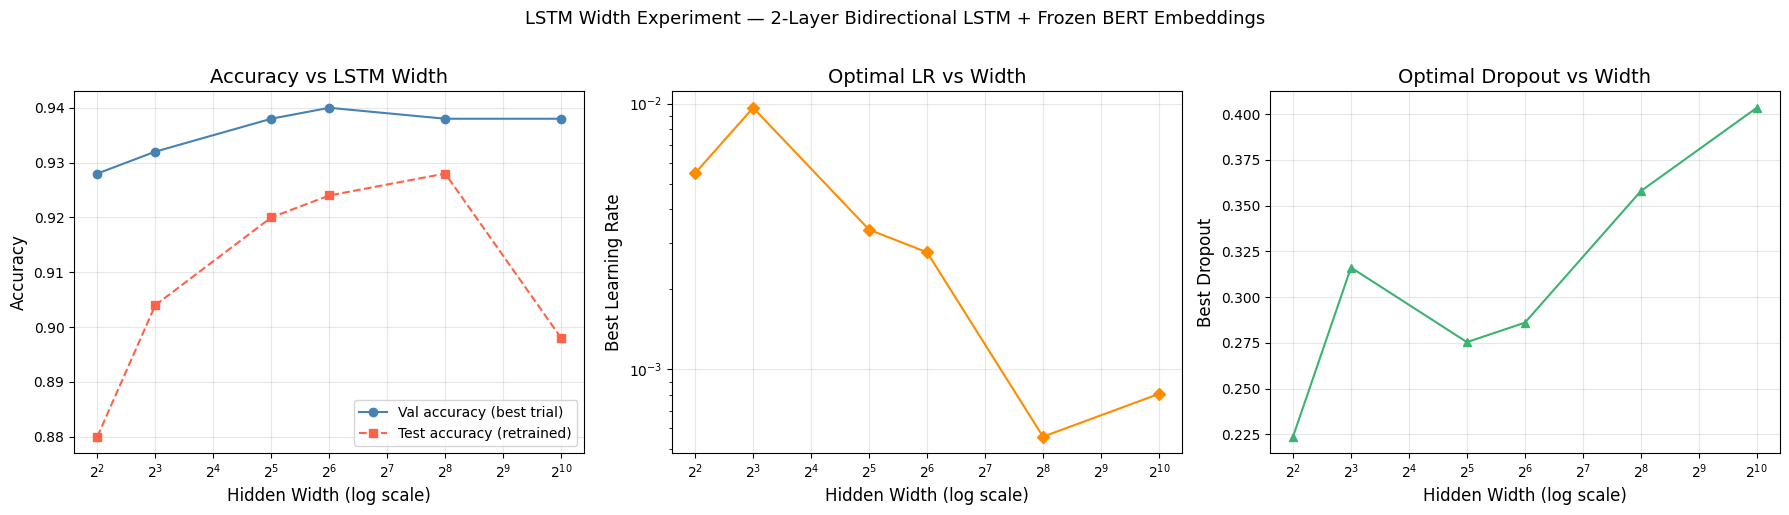

Saved: width_experiment_results.png


In [ ]:
widths_list = WIDTHS
val_accs  = [width_results[w]['study_val']  for w in widths_list]
test_accs = [width_results[w]['test_acc']   for w in widths_list]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Accuracy vs width ---
ax = axes[0]
ax.plot(widths_list, val_accs,  'o-', color='steelblue', label='Val accuracy (best trial)')
ax.plot(widths_list, test_accs, 's--', color='tomato',    label='Test accuracy (retrained)')
ax.set_xscale('log', base=2)
ax.set_xlabel('Hidden Width (log scale)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy vs LSTM Width', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# --- Panel 2: Best learning rate vs width ---
best_lrs = [float(width_results[w]['best_params']['learning_rate']) for w in widths_list]
ax2 = axes[1]
ax2.plot(widths_list, best_lrs, 'D-', color='darkorange')
ax2.set_xscale('log', base=2)
ax2.set_yscale('log')
ax2.set_xlabel('Hidden Width (log scale)', fontsize=12)
ax2.set_ylabel('Best Learning Rate', fontsize=12)
ax2.set_title('Optimal LR vs Width', fontsize=14)
ax2.grid(True, alpha=0.3)

# --- Panel 3: Best dropout vs width ---
best_dropouts = [float(width_results[w]['best_params']['dropout']) for w in widths_list]
ax3 = axes[2]
ax3.plot(widths_list, best_dropouts, '^-', color='mediumseagreen')
ax3.set_xscale('log', base=2)
ax3.set_xlabel('Hidden Width (log scale)', fontsize=12)
ax3.set_ylabel('Best Dropout', fontsize=12)
ax3.set_title('Optimal Dropout vs Width', fontsize=14)
ax3.grid(True, alpha=0.3)

plt.suptitle('LSTM Width Experiment — 2-Layer Bidirectional LSTM + Frozen BERT Embeddings',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('width_experiment_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: width_experiment_results.png")

## Plots Observations:

**Left plot (Accuracy vs Width) —** the *validation accuracy (blue solid line)* stays remarkably flat across all widths, hovering between 0.928 and 0.940.

The *test accuracy (red dashed line)* tells a more interesting story, it rises steadily from width 4 to 256 but then drops noticeably at width 1024, creating an inverted-U shape that clearly marks where the model starts to overfit or becomes harder to train.

**Left plot gap between val and test —** there is a consistent gap between validation and test accuracy across all widths, with validation always running higher. This gap is widest at width 4 and narrows as width increases up to 256, suggesting that moderate width helps generalization, but the gap widens again at width 1024 confirming that the largest model generalizes the worst despite its high validation score.

Width 256 Performs best for val and test accuracy gap.


**Middle plot (Optimal LR vs Width) —** the learning rate peaks sharply at width 8 (near 1e-2) and then drops steadily by nearly an order of magnitude as width grows, reaching around 8e-4 at width 1024. This downward trend is clean and consistent, showing that Optuna reliably discovered that larger networks require more conservative updates to train. On Width 256 learning late is lowest

**Right plot (Optimal Dropout vs Width) —** the dropout trend is generally increasing from 0.22 at width 4 up to 0.40 at width 1024.

## 9. Hyperparameter Trends Across Widths

In [ ]:
print("=" * 70)
print("DETAILED HYPERPARAMETER REPORT")
print("=" * 70)
for w in WIDTHS:
    r  = width_results[w]
    bp = r['best_params']
    print(f"\nWidth={w:5d} | Test Acc={r['test_acc']:.4f} | Val Acc={r['study_val']:.4f}")
    print(f"  LR={bp['learning_rate']:.2e}  WD={bp['weight_decay']:.2e}  "
          f"Dropout={bp['dropout']:.3f}  Patience={bp['patience']}")

DETAILED HYPERPARAMETER REPORT

Width=    4 | Test Acc=0.8800 | Val Acc=0.9280
  LR=5.47e-03  WD=8.13e-04  Dropout=0.224  Patience=38

Width=    8 | Test Acc=0.9040 | Val Acc=0.9320
  LR=9.64e-03  WD=2.27e-04  Dropout=0.316  Patience=26

Width=   32 | Test Acc=0.9200 | Val Acc=0.9380
  LR=3.35e-03  WD=2.27e-03  Dropout=0.275  Patience=32

Width=   64 | Test Acc=0.9240 | Val Acc=0.9400
  LR=2.76e-03  WD=1.90e-03  Dropout=0.286  Patience=40

Width=  256 | Test Acc=0.9280 | Val Acc=0.9380
  LR=5.59e-04  WD=4.18e-03  Dropout=0.358  Patience=38

Width= 1024 | Test Acc=0.8980 | Val Acc=0.9380
  LR=8.09e-04  WD=1.67e-05  Dropout=0.404  Patience=31


## Key Observations:

**Weight decay has no consistent trend —** it jumps around with no clear pattern (8.13e-04 at width 4, drops to 1.67e-05 at width 1024, but peaks at 4.18e-03 at width 256), suggesting weight decay is the least important hyperparameter here and Optuna never found a reliable relationship between model size and how much L2 regularization is needed.

**The val-test gap at width 1024 is the largest in the entire experiment —** val accuracy is 0.9380 but test accuracy is only 0.8980, a gap of 4 full percentage points, which is a strong warning sign that the largest model is overfitting to the validation set during the Optuna search itself, not just to the training data.

## 10. Discussion

## Option 1: Finding Diminishing Returns for LSTM
In this experiment I tested six LSTM hidden widths (4, 8, 32, 64, 256, 1024) using a 2-layer bidirectional LSTM with frozen BERT embeddings on the FinancialPhrasebank dataset. For each width I ran 15 Optuna trials tuning learning rate, weight decay, dropout, and patience (early stopping).

### Model Performance:
Test accuracy improved steadily from 88.0% at width 4 up to 92.8% at width 256, then dropped back to 89.8% at width 1024. The biggest gains came early — width 4 to 32 gave a 4 percentage point jump — while going from 32 all the way to 1024 gave essentially nothing and eventually reversed. This confirms a clear diminishing returns pattern with the optimal range around width 64–256.

### Hyperparameter Trends:


1.   Learning rate consistently decreased as width grew (5.47e-03 at width 4 down to 8.09e-04 at width 1024), showing larger models need smaller update steps.
2.   Dropout increased steadily with width (0.224 to 0.404), reflecting greater regularization needs.
3. Weight decay showed no consistent trend, suggesting it is the least important of the four hyperparameters.
4. The largest model (width 1024) showed a 4-point gap between val (93.8%) and test (89.8%) accuracy, the widest gap in the experiment, indicating it was overfitting during the Optuna search itself.



### Embeddings vs Architecture:

The most important finding is that even the tiny width-4 model (~25K parameters) achieved 88% accuracy. This tells us the frozen BERT embeddings are doing most of the work, they already encode rich contextual information, so the LSTM only needs to aggregate it. Width matters at the margins, but the embedding quality matters far more than LSTM architecture.

---

## 11. Extra Credit — Are Some Sentences Intrinsically Difficult?

We tracked the prediction outcome (correct / incorrect) for every example in the combined validation + test set across **all** Optuna trials and retrained best models (i.e., across all widths). For each example, we compute its accuracy (fraction of models that classified it correctly).

In [ ]:
# Compute per-example accuracy across all models
per_example_acc = per_example_correct / per_example_total

print(f"Total models evaluated per example: {per_example_total[0]}")
print(f"\nAccuracy distribution across examples:")
print(f"  Mean   : {per_example_acc.mean():.4f}")
print(f"  Median : {np.median(per_example_acc):.4f}")
print(f"  Min    : {per_example_acc.min():.4f}")
print(f"  Max    : {per_example_acc.max():.4f}")

# Count examples that were never correctly classified
always_wrong = (per_example_acc == 0.0).sum()
# Count examples that were always correctly classified
always_right = (per_example_acc == 1.0).sum()
print(f"\nAlways wrong (0% accuracy): {always_wrong}/{n_combined} examples")
print(f"Always right (100% accuracy): {always_right}/{n_combined} examples")

Total models evaluated per example: 96

Accuracy distribution across examples:
  Mean   : 0.8492
  Median : 0.9844
  Min    : 0.0000
  Max    : 1.0000

Always wrong (0% accuracy): 5/1000 examples
Always right (100% accuracy): 445/1000 examples


## Key Observation:

*   445/1000 examples: Always right (100% accuracy)

*   whereas 5/1000 examples: always wrong by 96 models (96 models = 6 widths × (15 trials + 1 retrain)

*   Median (0.98) is greater than mean (0.85), which itself confirms that a small number of persistently hard examples are dragging the average down.









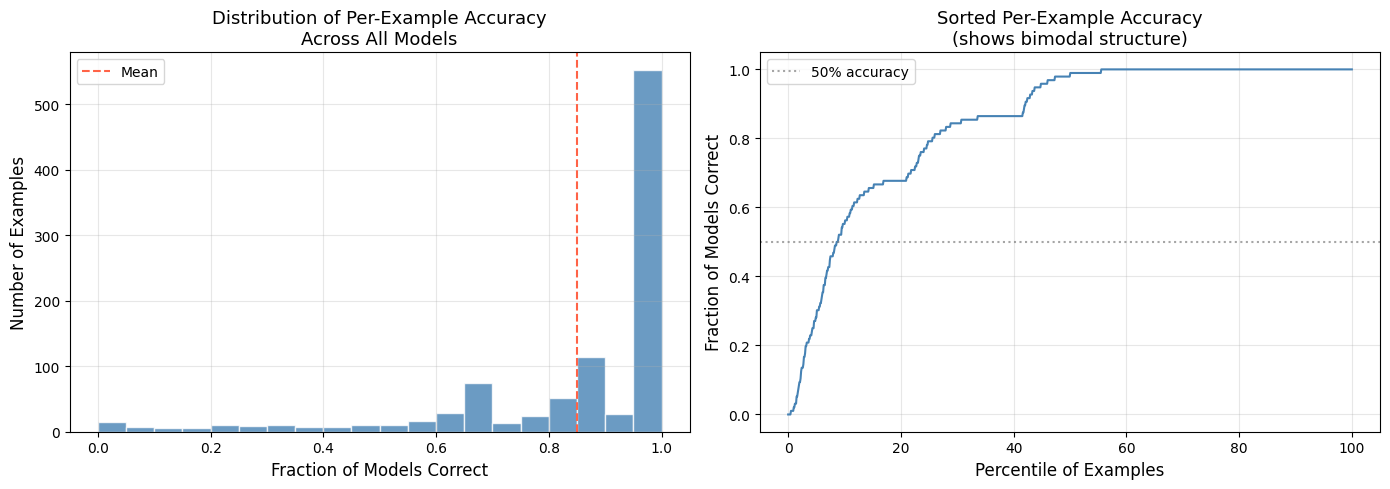

Saved: per_example_difficulty.png


In [ ]:
# Plot the distribution of per-example accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(per_example_acc, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Fraction of Models Correct', fontsize=12)
ax.set_ylabel('Number of Examples', fontsize=12)
ax.set_title('Distribution of Per-Example Accuracy\nAcross All Models', fontsize=13)
ax.axvline(per_example_acc.mean(), color='tomato', linestyle='--', label='Mean')
ax.legend()
ax.grid(True, alpha=0.3)

# Sorted accuracy curve
sorted_acc = np.sort(per_example_acc)
ax2 = axes[1]
ax2.plot(np.linspace(0, 100, n_combined), sorted_acc, color='steelblue')
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.7, label='50% accuracy')
ax2.set_xlabel('Percentile of Examples', fontsize=12)
ax2.set_ylabel('Fraction of Models Correct', fontsize=12)
ax2.set_title('Sorted Per-Example Accuracy\n(shows bimodal structure)', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('per_example_difficulty.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: per_example_difficulty.png")

## Plot Observations:

**The histogram (left)** shows a strongly bimodal distribution — the vast majority of examples sit at the far right at 100% accuracy, meaning almost every model got them right every time. Meanwhile a small but clear cluster of examples sits near 0%, meaning they were consistently wrong across all 96 models. Mean = 0.85 which is less than median (0.98)


**The sorted curve (right)** reinforces this — it rises steeply in the bottom 20th percentile then flattens near 1.0, showing most examples are easy and only a minority are genuinely hard.

In [ ]:
# Identify and print the 5 most difficult examples
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

# Sort by difficulty ascending (lowest accuracy = most difficult)
difficulty_order = np.argsort(per_example_acc)

print("=" * 75)
print("TOP 5 MOST DIFFICULT EXAMPLES")
print("(Ranked by fraction of models that classified them correctly)")
print("=" * 75)

for rank, idx in enumerate(difficulty_order[:5], start=1):
    text  = combined_texts[idx]
    label = combined_labels[idx]
    acc   = per_example_acc[idx]
    print(f"\nRank {rank}  |  Model accuracy: {acc:.2%}  |  True label: {label_names[label]}")
    print(f"Text: {text}")
    print("-" * 75)

TOP 5 MOST DIFFICULT EXAMPLES
(Ranked by fraction of models that classified them correctly)

Rank 1  |  Model accuracy: 0.00%  |  True label: Negative
Text: Finnish meat company Atria can no longer promise a sufficient amount of domestic beef to its customers .
---------------------------------------------------------------------------

Rank 2  |  Model accuracy: 0.00%  |  True label: Positive
Text: Previously , EB delivered a custom solution for LG Electronics and now is making it commercially available for other mobile terminal vendors as well as to wireless operators .
---------------------------------------------------------------------------

Rank 3  |  Model accuracy: 0.00%  |  True label: Negative
Text: The EU Commission said earlier it had fined ThyssenKrupp , United Technologies Corp 's Otis , Schindler AG and Kone Oyj a total of 992.3 mln eur for alleged cartel activity in the lift market going back twelve years .
--------------------------------------------------------------

## 12. Discussion: Intrinsically Difficult Examples

### Is there evidence of intrinsic difficulty?

#### Why are these 5 sentences hard?

**Rank 1 (Negative — Atria beef supply):** The sentence describes a supply shortage which is negative, but it contains no overtly negative financial language. Words like "cannot promise sufficient amount" are subtle and domain-specific — a general language model would not immediately flag this as negative sentiment.
Model should have flagged it negative because it has "no longer promise"

**Rank 2 (Positive — EB/LG Electronics):** This is genuinely ambiguous. It describes a product becoming commercially available, which is positive and a good clue, but the sentence structure is complex and passive. There is no clear positive signal word like "profit" or "growth" — the positivity is implied through business expansion context.

**Rank 3 (Negative — ThyssenKrupp cartel fine):** Surprisingly this was always wrong despite being clearly negative. The sentence is very long and packed with company names, numbers, and legal terminology. The model likely gets confused by the dense factual content and misses the negative sentiment buried inside it.

**Rank 4 (Positive — Incap new customers):** Signing "six new customers" is objectively positive but the sentence is dry and factual with no emotionally positive language. It reads more like a neutral press release announcement, so the model likely classifies it as neutral rather than positive.

**Rank 5 (Positive — steel heating optimization):** This describes energy savings from process optimization which is positive from a business perspective, but the language is purely technical. Without domain knowledge that energy reduction = cost savings = positive, the model has no linguistic cues to identify the sentiment correctly.

**Overall takeaway: ** The difficult sentences share a common theme: they require domain knowledge or contextual reasoning beyond what surface level language patterns can provide. The BERT embeddings, while powerful, were pretrained on general text and miss these finance-specific signals, which is why even the best models failed on them consistently regardless of width.

In [ ]:
# Summary statistics on difficult examples by class
print("Per-class accuracy of the 5 hardest examples:")
for rank, idx in enumerate(difficulty_order[:5], start=1):
    label = combined_labels[idx]
    print(f"  Rank {rank}: True label = {label_names[label]}  "
          f"({per_example_acc[idx]:.2%} of models correct)")

# Class-level breakdown of average difficulty
print("\nAverage per-example accuracy by true class:")
for cls in [0, 1, 2]:
    mask = (combined_labels_arr == cls)
    print(f"  {label_names[cls]:8s}: {per_example_acc[mask].mean():.4f}  "
          f"(n={mask.sum()})")

Per-class accuracy of the 5 hardest examples:
  Rank 1: True label = Negative  (0.00% of models correct)
  Rank 2: True label = Positive  (0.00% of models correct)
  Rank 3: True label = Negative  (0.00% of models correct)
  Rank 4: True label = Positive  (0.00% of models correct)
  Rank 5: True label = Positive  (0.00% of models correct)

Average per-example accuracy by true class:
  Negative: 0.5152  (n=138)
  Neutral : 0.9779  (n=612)
  Positive: 0.7185  (n=250)


**The class-level breakdown reveals an interesting insight, it has a striking class imbalance:**


*   Neutral sentences were classified almost perfectly (97.8%) across all models
*   while Negative sentences were the hardest class overall with only 51.5% average accuracy, barely better than random guessing

*   Positive sentences fell in between at 71.9%, suggesting the model has a reasonable but imperfect grasp of positive financial language


 This pattern makes intuitive sense, neutral financial statements tend to use bland, factual language that is easy to identify, while negative and positive sentiments in financial text are often expressed subtly or indirectly, making them much harder to distinguish from each other.

 The fact that 3 of the 5 hardest examples are Positive and 2 are Negative, with zero Neutral examples in the bottom 5, directly confirms that Neutral is the "easy" class and the real classification challenge lies in separating Negative from Positive.

In [ ]:
print("\n" + "=" * 70)
print("EXPERIMENT COMPLETE")
print("=" * 70)
print("\nFinal results summary:")
print(results_df.to_string(index=False))


EXPERIMENT COMPLETE

Final results summary:
 Width  Params (approx)       LR Weight Decay Dropout  Patience Best Val Acc Test Acc
     4            24736 5.47e-03     8.13e-04   0.224        38       0.9280   0.8800
     8            49728 9.64e-03     2.27e-04   0.316        26       0.9320   0.9040
    32           205056 3.35e-03     2.27e-03   0.275        32       0.9380   0.9200
    64           426496 2.76e-03     1.90e-03   0.286        40       0.9400   0.9240
   256          2099200 5.59e-04     4.18e-03   0.358        38       0.9380   0.9280
  1024         14688256 8.09e-04     1.67e-05   0.404        31       0.9380   0.8980


________________________________________________________________________